# 09. Grid search: la mejor combinación de parámetros

Los notebooks 04-08 mueven los parámetros uno a uno. Aquí busco la mejor combinación simultánea de todos:

| Parámetro | Opciones |
|---|---|
| Ventana de entrenamiento | expanding, sliding 3/4/5/6/7/9 |
| Umbral EV mínimo | 3%, 4%, 5%, 6%, 7%, 10% |
| Filtro de cuotas | base, base+X[3.50-4.50), base+X[3.70-4.50), solo_X |
| Ratio modelo/mercado | sin filtro, <=1.15, <=1.20, <=1.25 |
| Kill switch | activo (umbral 0.08) o desactivado |

Total: 1344 combinaciones.

## Validación en dos fases (anti-overfitting)

- In-sample: 2012-2019 (8 temporadas), busco las mejores combinaciones.
- Out-of-sample: 2020-2024 (5 temporadas), valido las top 10. Si siguen ganando OOS, la cosa es más creíble.

## Optimización de cómputo

Las predicciones del modelo solo dependen de la ventana de entrenamiento, no de los filtros. Las pre-calculo una vez por (ventana, temporada): 7 ventanas x 13 temporadas = 91 entrenamientos en lugar de 1344. Después el grid es solo aplicar filtros sobre las predicciones cacheadas, lo cual es instantáneo.

In [13]:
import pandas as pd
import numpy as np
import warnings
import itertools
import json
from tqdm import tqdm
warnings.filterwarnings('ignore')
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt

DATA_PATH  = '../data/df_final_clean.csv'
FEATURES   = [
    'Home_Elo_Calc','Away_Elo_Calc','Elo_Diff',
    'Home_Market_Value','Away_Market_Value','Log_Value_Diff',
    'Diff_FIFA_Ova','Diff_FIFA_Mid','Diff_FIFA_Def','Diff_FIFA_Att',
    'Home_Streak_L5','Away_Streak_L5',
    'Home_H2H_L3','Away_H2H_L3',
]
with open('../results/best_params.json') as f:
    _bp = json.load(f)
XGB_PARAMS = {**_bp, 'objective':'multi:softprob', 'num_class':3,
              'eval_metric':'mlogloss', 'random_state':42, 'verbosity':0, 'n_jobs':-1}

INIT_BK    = 1000.0
FLAT_STAKE = 10.0
KILL_MIN   = 15
FIRST_TEST = 2012
IS_END     = 2019   # in-sample: 2012-2019
OOS_START  = 2020   # out-of-sample: 2020-2024
MIN_BETS   = 25     # minimo de apuestas para considerar una configuracion valida

# Grid de parametros
WINDOWS      = [None, 3, 4, 5, 6, 7, 9]   # None = expanding
EV_GRID      = [0.03, 0.04, 0.05, 0.06, 0.07, 0.10]
FILTER_MAP   = {
    'base':             [('1',1.40,1.70),('1',2.00,2.50)],
    'base+X[3.50-4.50)':[('1',1.40,1.70),('1',2.00,2.50),('X',3.50,4.50)],
    'base+X[3.70-4.50)':[('1',1.40,1.70),('1',2.00,2.50),('X',3.70,4.50)],
    'solo_X[3.50-4.50)':[('X',3.50,4.50)],
}
RATIO_GRID   = [None, 1.15, 1.20, 1.25]
KILL_GRID    = [None, 0.08]   # None = sin kill switch

n_combos = len(WINDOWS)*len(EV_GRID)*len(FILTER_MAP)*len(RATIO_GRID)*len(KILL_GRID)
print(f'Combinaciones totales: {n_combos}')
print(f'In-sample : 2012-{IS_END} | Out-of-sample: {OOS_START}-2024')

Combinaciones totales: 1344
In-sample : 2012-2019 | Out-of-sample: 2020-2024


In [14]:
def build_elo(df, k=30, ha=100, start=1500):
    ratings = {}
    h_elos, a_elos = [], []
    for _, row in df.iterrows():
        h, a, ftr = row['HomeTeam'], row['AwayTeam'], row['FTR']
        rh = ratings.get(h, start); ra = ratings.get(a, start)
        h_elos.append(rh); a_elos.append(ra)
        e_h = 1.0 / (1.0 + 10**((ra - (rh + ha)) / 400.0))
        s_h, s_a = (1,0) if ftr=='H' else ((0.5,0.5) if ftr=='D' else (0,1))
        ratings[h] = rh + k*(s_h - e_h)
        ratings[a] = ra + k*(s_a - (1 - e_h))
    return h_elos, a_elos

df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df = df[df['FTR'].isin(['H','D','A'])].dropna(subset=['Season']).copy()
df['Season'] = df['Season'].astype(int)
df = df.sort_values('Date').reset_index(drop=True)
df['Home_Elo_Calc'], df['Away_Elo_Calc'] = build_elo(df)
df['Elo_Diff'] = df['Home_Elo_Calc'] - df['Away_Elo_Calc']
for c in FEATURES:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)
df = df.dropna(subset=FEATURES+['Target','B365H','B365D','B365A'])
all_seasons  = sorted(df['Season'].unique())
test_seasons = [s for s in all_seasons if s >= FIRST_TEST]
is_seasons   = [s for s in test_seasons if s <= IS_END]
oos_seasons  = [s for s in test_seasons if s >= OOS_START]
print(f'Dataset: {len(df)} partidos')
print(f'In-sample seasons : {is_seasons}')
print(f'Out-of-sample seasons: {oos_seasons}')

Dataset: 5700 partidos
In-sample seasons : [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]
Out-of-sample seasons: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


## Fase 1: pre-cómputo de predicciones

Entreno el modelo para cada (ventana, temporada de test) y guardo las probabilidades. Es el único paso lento (~5 min).

In [15]:
def window_label(w):
    return 'expanding' if w is None else f'sliding_{w}'

# cache[window_label][test_season] = {df_te, p_H, p_D, p_A}
cache = {}

for window in tqdm(WINDOWS, desc='Pre-computando ventanas'):
    wlabel = window_label(window)
    cache[wlabel] = {}

    for test_s in test_seasons:
        prior = [s for s in all_seasons if s < test_s]
        tr_s  = prior if window is None else prior[-window:]
        if not tr_s: continue

        tr = df['Season'].isin(tr_s)
        te = df['Season'] == test_s
        X_tr = df.loc[tr, FEATURES].values
        y_tr = df.loc[tr, 'Target'].values
        df_te = df[te].reset_index(drop=True)
        if len(X_tr) < 50 or len(df_te) == 0: continue

        model = CalibratedClassifierCV(XGBClassifier(**XGB_PARAMS),
                                        method='isotonic', cv=TimeSeriesSplit(n_splits=3))
        model.fit(X_tr, y_tr)
        proba   = model.predict_proba(df_te[FEATURES].values)
        classes = list(model.classes_)

        cache[wlabel][test_s] = {
            'df_te': df_te,
            'p_H':   proba[:, classes.index(2)],
            'p_D':   proba[:, classes.index(1)],
            'p_A':   proba[:, classes.index(0)],
        }

print(f'Cache listo: {len(cache)} ventanas x {len(test_seasons)} temporadas')

Pre-computando ventanas: 100%|██████████| 7/7 [03:39<00:00, 31.41s/it]

Cache listo: 7 ventanas x 13 temporadas


## Fase 2: grid search

Aplico las 1344 combinaciones sobre las predicciones cacheadas. Son solo filtros sobre dataframes, no hay más entrenamientos.

In [16]:
def evaluate(wlabel, seasons_subset, min_ev, odds_filter, max_ratio, kill_thr):
    """Evalua una configuracion sobre un conjunto de temporadas usando el cache."""
    all_bets, season_rois = [], []

    for test_s in seasons_subset:
        if wlabel not in cache or test_s not in cache[wlabel]:
            continue
        c     = cache[wlabel][test_s]
        df_te = c['df_te']
        p_H, p_D, p_A = c['p_H'], c['p_D'], c['p_A']

        bets = []; killed = False
        for i, row in df_te.iterrows():
            if killed: break
            oh = float(row['B365H']); od = float(row['B365D']); oa = float(row['B365A'])
            if oh < 1.05 or od < 1.05 or oa < 1.05: continue
            ftr = str(row['FTR'])
            for bt, p, odds, won in [('1',p_H[i],oh,ftr=='H'),
                                      ('X',p_D[i],od,ftr=='D'),
                                      ('2',p_A[i],oa,ftr=='A')]:
                ev = p * odds - 1
                if ev <= min_ev: continue
                if not any(bt==b and lo<=odds<hi for b,lo,hi in odds_filter): continue
                if max_ratio is not None:
                    implied = 1.0 / odds
                    if implied > 0 and (p / implied) > max_ratio: continue
                profit = FLAT_STAKE*(odds-1) if won else -FLAT_STAKE
                bets.append({'P_Model': p, 'Won': int(won), 'Profit': profit})

            if kill_thr is not None and len(bets) >= KILL_MIN:
                obs = np.mean([b['Won']     for b in bets])
                exp = np.mean([b['P_Model'] for b in bets])
                if obs < exp - kill_thr: killed = True

        if bets:
            b   = pd.DataFrame(bets)
            roi = b['Profit'].sum() / (len(b) * FLAT_STAKE)
            season_rois.append(roi)
            all_bets.extend(bets)

    if not all_bets:
        return {'roi': 0.0, 'n_bets': 0, 'pos': 0, 'n_seasons': 0, 'bk': INIT_BK}

    ab  = pd.DataFrame(all_bets)
    roi = ab['Profit'].sum() / (len(ab) * FLAT_STAKE)
    pos = sum(r > 0 for r in season_rois)
    bk  = INIT_BK + ab['Profit'].sum()
    return {'roi': roi, 'n_bets': len(ab), 'pos': pos,
            'n_seasons': len(season_rois), 'bk': bk}

print('Funcion evaluate definida.')

Funcion evaluate definida.


In [17]:
combos = list(itertools.product(WINDOWS, EV_GRID,
                                 list(FILTER_MAP.keys()), RATIO_GRID, KILL_GRID))
print(f'Ejecutando {len(combos)} combinaciones sobre in-sample (2012-{IS_END})...')

is_results = []
for window, min_ev, filter_name, max_ratio, kill_thr in tqdm(combos):
    wlabel = window_label(window)
    filt   = FILTER_MAP[filter_name]
    r      = evaluate(wlabel, is_seasons, min_ev, filt, max_ratio, kill_thr)
    is_results.append({
        'window':     'expanding' if window is None else f'sliding_{window}',
        'min_ev':     min_ev,
        'filter':     filter_name,
        'max_ratio':  max_ratio if max_ratio else 'none',
        'kill_switch': 'si' if kill_thr else 'no',
        'is_roi':     round(r['roi'], 4),
        'is_bets':    r['n_bets'],
        'is_pos':     r['pos'],
        'is_seasons': r['n_seasons'],
        'is_bk':      round(r['bk'], 1),
    })

df_is = pd.DataFrame(is_results)
# Filtrar combinaciones con pocas apuestas (no fiables)
df_is_valid = df_is[df_is['is_bets'] >= MIN_BETS].copy()
df_is_valid = df_is_valid.sort_values('is_roi', ascending=False).reset_index(drop=True)
print(f'\nCombinaciones validas (>={MIN_BETS} apuestas): {len(df_is_valid)} de {len(df_is)}')
print(f'Combinaciones con ROI positivo: {(df_is_valid["is_roi"] > 0).sum()}')

Ejecutando 1344 combinaciones sobre in-sample (2012-2019)...


100%|██████████| 1344/1344 [03:30<00:00,  6.40it/s]


Combinaciones validas (>=25 apuestas): 1340 de 1344
Combinaciones con ROI positivo: 486


## Top 20 in-sample (2012-2019)

In [18]:
top20 = df_is_valid.head(20).copy()
top20['is_roi_pct'] = (top20['is_roi']*100).round(2)
top20['consistencia'] = top20['is_pos'].astype(str) + '/' + top20['is_seasons'].astype(str)

print('TOP 20 combinaciones — in-sample (2012-2019):')
print(top20[['window','min_ev','filter','max_ratio','kill_switch',
              'is_roi_pct','is_bets','consistencia','is_bk']].to_string(index=True))

TOP 20 combinaciones — in-sample (2012-2019):
       window  min_ev             filter max_ratio kill_switch  is_roi_pct  is_bets consistencia   is_bk
0   sliding_5    0.10  solo_X[3.50-4.50)      1.15          no       19.22       37          4/8  1071.1
1   sliding_5    0.10  solo_X[3.50-4.50)      1.15          si       19.22       37          4/8  1071.1
2   sliding_4    0.10  solo_X[3.50-4.50)       1.2          si       17.96       51          6/8  1091.6
3   sliding_4    0.10  solo_X[3.50-4.50)       1.2          no       17.96       51          6/8  1091.6
4   sliding_5    0.10  base+X[3.70-4.50)      1.15          no       15.75      115          4/8  1181.1
5   sliding_4    0.10  solo_X[3.50-4.50)      none          si       13.50       74          6/8  1099.9
6   sliding_4    0.10  solo_X[3.50-4.50)      none          no       13.50       74          6/8  1099.9
7   sliding_4    0.10  solo_X[3.50-4.50)      1.15          si       12.61       28          5/8  1035.3
8   slidi

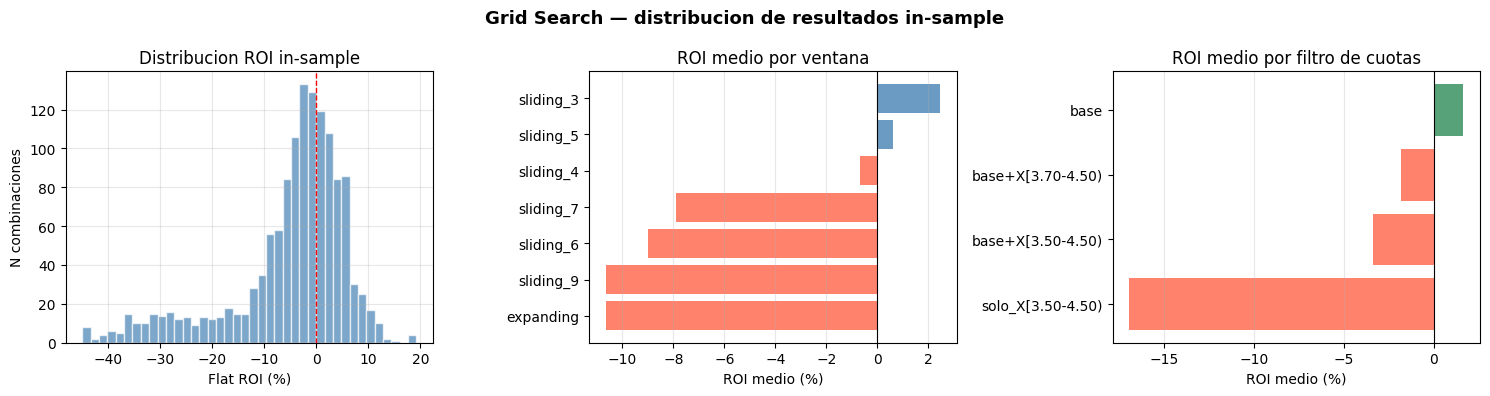

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribucion de ROI in-sample
axes[0].hist(df_is_valid['is_roi']*100, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Flat ROI (%)'); axes[0].set_ylabel('N combinaciones')
axes[0].set_title('Distribucion ROI in-sample')
axes[0].grid(alpha=0.3)

# ROI medio por ventana
roi_window = df_is_valid.groupby('window')['is_roi'].mean().sort_values()
axes[1].barh(roi_window.index, roi_window.values*100,
             color=['tomato' if r<0 else 'steelblue' for r in roi_window.values], alpha=0.8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('ROI medio (%)'); axes[1].set_title('ROI medio por ventana')
axes[1].grid(axis='x', alpha=0.3)

# ROI medio por filtro
roi_filter = df_is_valid.groupby('filter')['is_roi'].mean().sort_values()
axes[2].barh(roi_filter.index, roi_filter.values*100,
             color=['tomato' if r<0 else 'seagreen' for r in roi_filter.values], alpha=0.8)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_xlabel('ROI medio (%)'); axes[2].set_title('ROI medio por filtro de cuotas')
axes[2].grid(axis='x', alpha=0.3)

plt.suptitle('Grid Search — distribucion de resultados in-sample', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/grid_search_is_overview.png', dpi=120, bbox_inches='tight')
plt.show()

## Fase 3: validación out-of-sample (2020-2024)

Cojo las top 10 in-sample y las evalúo en 2020-2024, que el modelo no ha visto durante la búsqueda. Si siguen siendo rentables ahí, el resultado es robusto.

Criterio de robustez: una combinación es válida si:

1. ROI positivo en out-of-sample.
2. Al menos 2/5 temporadas OOS positivas.

In [20]:
top10 = df_is_valid.head(10).copy()

oos_rows = []
for _, row in top10.iterrows():
    window = None if row['window'] == 'expanding' else int(row['window'].split('_')[1])
    wlabel = window_label(window)
    filt   = FILTER_MAP[row['filter']]
    ev     = row['min_ev']
    ratio  = None if row['max_ratio'] == 'none' else float(row['max_ratio'])
    kill   = 0.08 if row['kill_switch'] == 'si' else None

    r_oos = evaluate(wlabel, oos_seasons, ev, filt, ratio, kill)
    r_full = evaluate(wlabel, test_seasons, ev, filt, ratio, kill)

    oos_rows.append({
        **{k: row[k] for k in ['window','min_ev','filter','max_ratio','kill_switch']},
        'is_roi':    row['is_roi'],
        'is_bets':   row['is_bets'],
        'is_pos':    f"{row['is_pos']}/{row['is_seasons']}",
        'oos_roi':   round(r_oos['roi'], 4),
        'oos_bets':  r_oos['n_bets'],
        'oos_pos':   f"{r_oos['pos']}/{r_oos['n_seasons']}",
        'full_roi':  round(r_full['roi'], 4),
        'full_bets': r_full['n_bets'],
        'robust':    '✓' if r_oos['roi'] > 0 and r_oos['pos'] >= 2 else '✗',
    })

df_oos = pd.DataFrame(oos_rows)

print('=' * 100)
print('VALIDACION OUT-OF-SAMPLE: top 10 combinaciones in-sample evaluadas en 2020-2024')
print('=' * 100)
print(df_oos[['window','min_ev','filter','max_ratio','kill_switch',
               'is_roi','is_pos','oos_roi','oos_pos','full_roi','robust']].to_string(index=True))

VALIDACION OUT-OF-SAMPLE: top 10 combinaciones in-sample evaluadas en 2020-2024
      window  min_ev             filter max_ratio kill_switch  is_roi is_pos  oos_roi oos_pos  full_roi robust
0  sliding_5     0.1  solo_X[3.50-4.50)      1.15          no  0.1922    4/8   0.1519     3/5    0.1649      ✓
1  sliding_5     0.1  solo_X[3.50-4.50)      1.15          si  0.1922    4/8   0.1822     3/5    0.1855      ✓
2  sliding_4     0.1  solo_X[3.50-4.50)       1.2          si  0.1796    6/8   0.1239     3/5    0.1393      ✓
3  sliding_4     0.1  solo_X[3.50-4.50)       1.2          no  0.1796    6/8   0.0698     3/5    0.0987      ✓
4  sliding_5     0.1  base+X[3.70-4.50)      1.15          no  0.1575    4/8   0.0928     4/5    0.1281      ✓
5  sliding_4     0.1  solo_X[3.50-4.50)      none          si  0.1350    6/8   0.0441     1/5    0.0839      ✗
6  sliding_4     0.1  solo_X[3.50-4.50)      none          no  0.1350    6/8  -0.0061     3/5    0.0221      ✗
7  sliding_4     0.1  solo_X[3.5

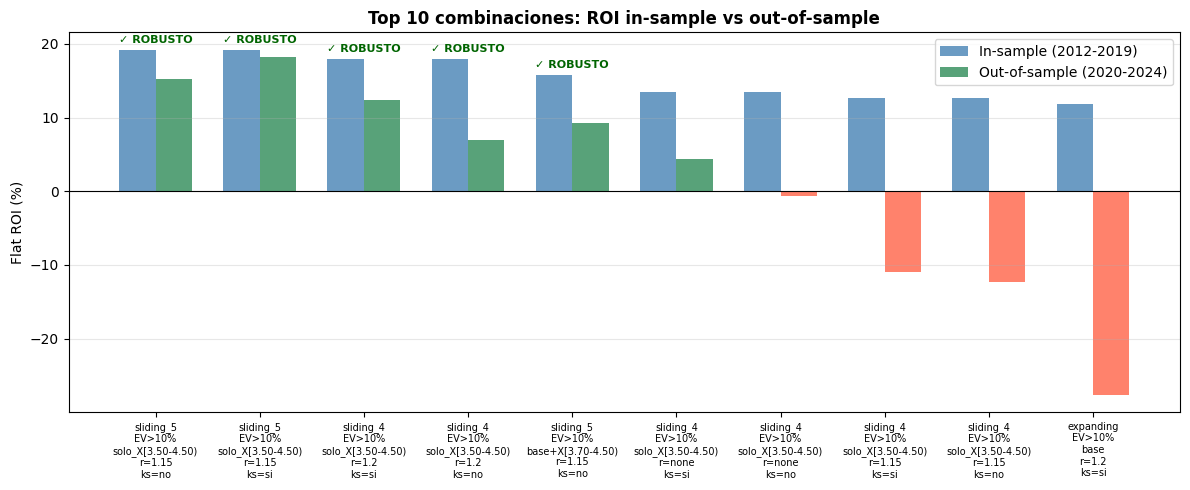

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))

x      = range(len(df_oos))
width  = 0.35
labels = [f"{r['window']}\nEV>{r['min_ev']:.0%}\n{r['filter']}\nr={r['max_ratio']}\nks={r['kill_switch']}"
          for _, r in df_oos.iterrows()]

bars_is  = ax.bar([i - width/2 for i in x], df_oos['is_roi']*100,
                   width, color='steelblue', alpha=0.8, label='In-sample (2012-2019)')
bars_oos = ax.bar([i + width/2 for i in x], df_oos['oos_roi']*100,
                   width,
                   color=['seagreen' if r > 0 else 'tomato' for r in df_oos['oos_roi']],
                   alpha=0.8, label='Out-of-sample (2020-2024)')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=7)
ax.set_ylabel('Flat ROI (%)')
ax.set_title('Top 10 combinaciones: ROI in-sample vs out-of-sample', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)

# Marcar las robustas
for i, (_, row) in enumerate(df_oos.iterrows()):
    if row['robust'] == '✓':
        ax.annotate('✓ ROBUSTO', xy=(i, max(row['is_roi'], row['oos_roi'])*100),
                    xytext=(0, 5), textcoords='offset points',
                    ha='center', fontsize=8, color='darkgreen', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/grid_search_oos_validation.png', dpi=120, bbox_inches='tight')
plt.show()

## Análisis de patrones: qué parámetros dominan entre los mejores

In [22]:
# Analisis de los top 50 in-sample: que parametros aparecen mas
top50 = df_is_valid.head(50)

print('=== DISTRIBUCION DE PARAMETROS EN TOP 50 IN-SAMPLE ===')
for col in ['window', 'min_ev', 'filter', 'max_ratio', 'kill_switch']:
    counts = top50[col].value_counts()
    print(f'\n{col}:')
    for val, cnt in counts.items():
        print(f'  {str(val):<25} {cnt:3} ({cnt/len(top50)*100:.0f}%)')

# ROI medio por valor de cada parametro
print('\n=== ROI MEDIO POR PARAMETRO (todas las combinaciones validas) ===')
for col in ['window', 'min_ev', 'filter', 'max_ratio', 'kill_switch']:
    roi_by = df_is_valid.groupby(col)['is_roi'].agg(['mean','count']).sort_values('mean', ascending=False)
    print(f'\n{col}:')
    for val, row2 in roi_by.iterrows():
        print(f'  {str(val):<25} roi_medio={row2["mean"]*100:+.2f}%  (n={row2["count"]})')

=== DISTRIBUCION DE PARAMETROS EN TOP 50 IN-SAMPLE ===

window:
  sliding_5                  21 (42%)
  sliding_3                  16 (32%)
  sliding_4                   8 (16%)
  expanding                   2 (4%)
  sliding_9                   2 (4%)
  sliding_7                   1 (2%)

min_ev:
  0.1                        27 (54%)
  0.06                        8 (16%)
  0.07                        7 (14%)
  0.05                        6 (12%)
  0.04                        2 (4%)

filter:
  base                       31 (62%)
  solo_X[3.50-4.50)          12 (24%)
  base+X[3.70-4.50)           6 (12%)
  base+X[3.50-4.50)           1 (2%)

max_ratio:
  1.2                        22 (44%)
  1.15                       18 (36%)
  none                        5 (10%)
  1.25                        5 (10%)

kill_switch:
  si                         27 (54%)
  no                         23 (46%)

=== ROI MEDIO POR PARAMETRO (todas las combinaciones validas) ===

window:
  sliding_3            

In [23]:
# Guardar resultados
df_is_valid.to_csv('../results/grid_search_is_results.csv', index=False)
df_oos.to_csv('../results/grid_search_oos_validation.csv', index=False)
print('Guardados: grid_search_is_results.csv y grid_search_oos_validation.csv')

# Resumen final
robust = df_oos[df_oos['robust'] == '✓']
print(f'\nCombinaciones robustas (positivas en IS y OOS): {len(robust)}')
if len(robust):
    print(robust[['window','min_ev','filter','max_ratio','kill_switch',
                   'is_roi','oos_roi','full_roi']].to_string(index=False))

Guardados: grid_search_is_results.csv y grid_search_oos_validation.csv

Combinaciones robustas (positivas en IS y OOS): 5
   window  min_ev            filter max_ratio kill_switch  is_roi  oos_roi  full_roi
sliding_5     0.1 solo_X[3.50-4.50)      1.15          no  0.1922   0.1519    0.1649
sliding_5     0.1 solo_X[3.50-4.50)      1.15          si  0.1922   0.1822    0.1855
sliding_4     0.1 solo_X[3.50-4.50)       1.2          si  0.1796   0.1239    0.1393
sliding_4     0.1 solo_X[3.50-4.50)       1.2          no  0.1796   0.0698    0.0987
sliding_5     0.1 base+X[3.70-4.50)      1.15          no  0.1575   0.0928    0.1281


## Evolución del bankroll de la mejor combinación robusta

Visualizando: mejor combinación robusta (IS+OOS positivos, OOS_pos>=2/5)
  ventana=sliding_5  EV>10%  filtro=solo_X[3.50-4.50)  ratio=1.15  kill=si
  IS ROI=+19.22%  OOS ROI=+18.22%  full ROI=+18.55%


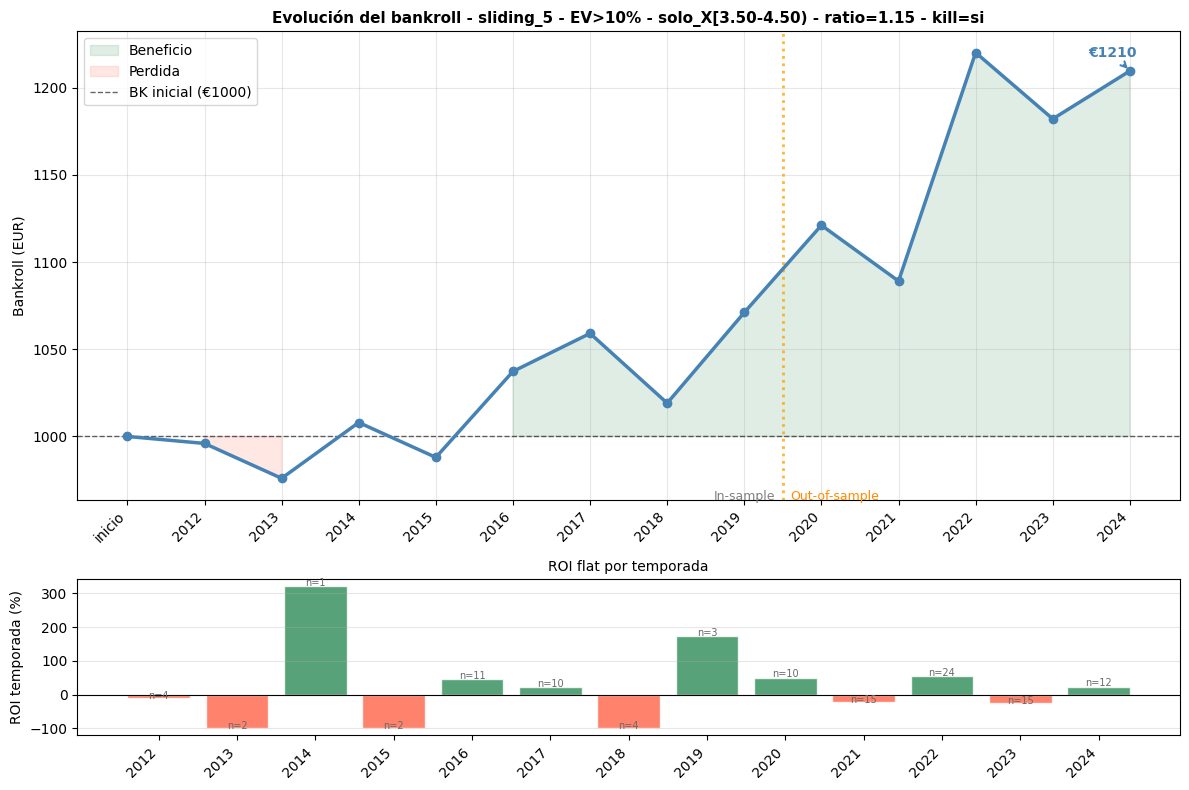


Detalle por temporada:
season  bets  profit    roi  bankroll
  2012     4    -4.0  -10.0     996.0
  2013     2   -20.0 -100.0     976.0
  2014     1    32.0  320.0    1008.0
  2015     2   -20.0 -100.0     988.0
  2016    11    49.3   44.8    1037.3
  2017    10    21.8   21.8    1059.1
  2018     4   -40.0 -100.0    1019.1
  2019     3    52.0  173.3    1071.1
  2020    10    50.0   50.0    1121.1
  2021    15   -32.0  -21.3    1089.1
  2022    24   131.0   54.6    1220.1
  2023    15   -38.0  -25.3    1182.1
  2024    12    27.5   22.9    1209.6


In [24]:
# Selección automática de la mejor combinación.
# Preferencia: combinación robusta (OOS>0 y OOS_pos>=2/5) con máximo full_roi.
# Fallback: top combinación por full_roi del top 10 IS.
robust_mask = (df_oos['oos_roi'] > 0) & df_oos['oos_pos'].str.split('/').str[0].astype(int).ge(2)
robust = df_oos[robust_mask].copy()
if not robust.empty:
    best = robust.sort_values('full_roi', ascending=False).iloc[0]
    best_label = 'mejor combinación robusta (IS+OOS positivos, OOS_pos>=2/5)'
else:
    best = df_oos.sort_values('full_roi', ascending=False).iloc[0]
    best_label = 'mejor combinación por full_roi del top 10 (NO robusta — falla criterio OOS)'

BEST_WINDOW = None if best['window'] == 'expanding' else int(best['window'].split('_')[1])
BEST_EV     = float(best['min_ev'])
BEST_FILTER = FILTER_MAP[best['filter']]
BEST_RATIO  = None if best['max_ratio'] == 'none' else float(best['max_ratio'])
BEST_KILL   = 0.08 if best['kill_switch'] == 'si' else None

print(f'Visualizando: {best_label}')
print(f'  ventana={best["window"]}  EV>{BEST_EV*100:.0f}%  filtro={best["filter"]}  '
      f'ratio={best["max_ratio"]}  kill={best["kill_switch"]}')
print(f'  IS ROI={best["is_roi"]*100:+.2f}%  OOS ROI={best["oos_roi"]*100:+.2f}%  '
      f'full ROI={best["full_roi"]*100:+.2f}%')

wlabel = window_label(BEST_WINDOW)

bankroll = INIT_BK
bk_history = [{'season': 'inicio', 'bankroll': bankroll, 'bets': 0, 'profit': 0.0, 'roi': 0.0}]

for test_s in test_seasons:
    if wlabel not in cache or test_s not in cache[wlabel]:
        continue
    c     = cache[wlabel][test_s]
    df_te = c['df_te']
    p_H, p_D, p_A = c['p_H'], c['p_D'], c['p_A']

    bets_full = []
    killed = False
    for i, row in df_te.iterrows():
        if killed: break
        oh = float(row['B365H']); od = float(row['B365D']); oa = float(row['B365A'])
        if oh < 1.05 or od < 1.05 or oa < 1.05: continue
        ftr = str(row['FTR'])
        for bt, p, odds, won in [('1',p_H[i],oh,ftr=='H'),
                                  ('X',p_D[i],od,ftr=='D'),
                                  ('2',p_A[i],oa,ftr=='A')]:
            ev = p * odds - 1
            if ev <= BEST_EV: continue
            if not any(bt==b and lo<=odds<hi for b,lo,hi in BEST_FILTER): continue
            if BEST_RATIO is not None:
                implied = 1.0 / odds
                if implied > 0 and (p / implied) > BEST_RATIO: continue
            profit = FLAT_STAKE*(odds-1) if won else -FLAT_STAKE
            bets_full.append({'P_Model': p, 'Won': int(won), 'Profit': profit})

        if BEST_KILL is not None and len(bets_full) >= KILL_MIN:
            obs = np.mean([b['Won']     for b in bets_full])
            exp = np.mean([b['P_Model'] for b in bets_full])
            if obs < exp - BEST_KILL:
                killed = True

    season_profit = sum(b['Profit'] for b in bets_full)
    bankroll += season_profit
    roi_s = season_profit / (len(bets_full) * FLAT_STAKE) if bets_full else 0.0
    bk_history.append({
        'season':   test_s,
        'bankroll': round(bankroll, 2),
        'bets':     len(bets_full),
        'profit':   round(season_profit, 2),
        'roi':      round(roi_s * 100, 1),
    })

df_bk = pd.DataFrame(bk_history)

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]})

seasons_plot = df_bk['season'].astype(str)
bk_vals      = df_bk['bankroll'].values
x_idx        = range(len(seasons_plot))

ax1.plot(x_idx, bk_vals, color='steelblue', linewidth=2.5, marker='o', markersize=6, zorder=3)
ax1.fill_between(x_idx, INIT_BK, bk_vals,
                 where=[b >= INIT_BK for b in bk_vals], alpha=0.15, color='seagreen', label='Beneficio')
ax1.fill_between(x_idx, INIT_BK, bk_vals,
                 where=[b < INIT_BK for b in bk_vals], alpha=0.15, color='tomato', label='Perdida')
ax1.axhline(INIT_BK, color='black', linestyle='--', linewidth=1, alpha=0.6, label=f'BK inicial (€{INIT_BK:.0f})')

is_idx  = [i for i, s in enumerate(df_bk['season']) if s != 'inicio' and int(s) <= IS_END]
oos_idx = [i for i, s in enumerate(df_bk['season']) if s != 'inicio' and int(s) >= OOS_START]
if is_idx and oos_idx:
    split = (is_idx[-1] + oos_idx[0]) / 2
    ax1.axvline(split, color='orange', linestyle=':', linewidth=2, alpha=0.8)
    ax1.text(split - 0.1, ax1.get_ylim()[0] if ax1.get_ylim()[0] > 0 else 970,
             'In-sample', ha='right', fontsize=9, color='gray')
    ax1.text(split + 0.1, ax1.get_ylim()[0] if ax1.get_ylim()[0] > 0 else 970,
             'Out-of-sample', ha='left', fontsize=9, color='darkorange')

ax1.annotate(f"€{bk_vals[-1]:.0f}", xy=(x_idx[-1], bk_vals[-1]),
             xytext=(-30, 10), textcoords='offset points',
             fontsize=10, fontweight='bold', color='steelblue',
             arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.5))

ax1.set_xticks(list(x_idx))
ax1.set_xticklabels(seasons_plot, rotation=45, ha='right')
ax1.set_ylabel('Bankroll (EUR)')
title_str = (f"Evolución del bankroll - {best['window']} - EV>{BEST_EV*100:.0f}% - "
             f"{best['filter']} - ratio={best['max_ratio']} - kill={best['kill_switch']}")
ax1.set_title(title_str, fontweight='bold', fontsize=11)
ax1.legend(loc='upper left'); ax1.grid(alpha=0.3)

df_seasons = df_bk[df_bk['season'] != 'inicio'].copy()
colors = ['seagreen' if r > 0 else 'tomato' for r in df_seasons['roi']]
bars = ax2.bar(range(len(df_seasons)), df_seasons['roi'], color=colors, alpha=0.8, edgecolor='white')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xticks(range(len(df_seasons)))
ax2.set_xticklabels(df_seasons['season'].astype(str), rotation=45, ha='right')
ax2.set_ylabel('ROI temporada (%)')
ax2.set_title('ROI flat por temporada', fontsize=10)
ax2.grid(axis='y', alpha=0.3)

for j, (_, row) in enumerate(df_seasons.iterrows()):
    if row['bets'] > 0:
        ax2.text(j, row['roi'] + (1 if row['roi'] >= 0 else -3),
                 f"n={row['bets']}", ha='center', fontsize=7, color='dimgray')

plt.tight_layout()
plt.savefig('../results/bankroll_evolution_best.png', dpi=130, bbox_inches='tight')
plt.show()

print('\nDetalle por temporada:')
print(df_bk[df_bk['season'] != 'inicio'][['season','bets','profit','roi','bankroll']].to_string(index=False))


## Conclusiones

### Resultados del grid

De las 1344 combinaciones (1340 válidas con >=25 apuestas), 486 dan ROI positivo in-sample (36%). De las top-10 in-sample, evaluadas en out-of-sample con el criterio de robustez (ROI positivo IS+OOS y >=2/5 temporadas OOS positivas), **5 sobreviven**:

| # | Ventana | EV | Filtro | Ratio | Kill | IS ROI | OOS ROI | OOS pos | Full ROI | Robusta |
|---|---|---|---|---|---|---|---|---|---|---|
| 1 | sliding_5 | 0.10 | solo_X[3.50-4.50) | 1.15 | no | +19.22% | +15.19% | 3/5 | +16.49% | sí |
| 2 | **sliding_5** | **0.10** | **solo_X[3.50-4.50)** | **1.15** | **si** | **+19.22%** | **+18.22%** | **3/5** | **+18.55%** | **sí** |
| 3 | sliding_4 | 0.10 | solo_X[3.50-4.50) | 1.20 | si | +17.96% | +12.39% | 3/5 | +13.93% | sí |
| 4 | sliding_4 | 0.10 | solo_X[3.50-4.50) | 1.20 | no | +17.96% | +6.98% | 3/5 | +9.87% | sí |
| 5 | sliding_5 | 0.10 | base+X[3.70-4.50) | 1.15 | no | +15.75% | +9.28% | 4/5 | +12.81% | sí |

La mejor robusta es **sliding_5 + EV>10% + solo_X[3.50-4.50) + ratio<=1.15 + kill=si** con full ROI +18.55% e IS y OOS ambos por encima de +18%, una consistencia muy buena. Las cuatro siguientes también superan el criterio.

### Hallazgo principal: el nicho del empate sí emerge

Cuatro de las cinco robustas usan `solo_X[3.50-4.50)`: el nicho que el notebook 06 marcaba como "no rentable claramente" pero que aquí, refinado con EV>10% y ratio<=1.15, sí genera yield robusto entre IS y OOS. La quinta robusta usa `base+X[3.70-4.50)`, que también tiene componente de empate.

Es un patrón que cuesta atribuir solo al azar: 5 combinaciones del top-10 superan validación temporal estricta, y 4 de ellas comparten el mismo filtro (solo_X[3.50-4.50)) con variaciones menores en ventana, ratio y kill switch. Esto coincide con el hallazgo del notebook 06 sobre X[3.70-4.50), pero el grid lo refina y le da más solidez.

### Lectura cruzada con los notebooks 03 y 06

El notebook 06 mostraba que el empate en X[3.50-4.50) por sí solo no parecía dar edge claro (hit rate ~26% ≈ implícita), pero que con kill switch y filtros adicionales había yields positivos puntuales. El grid lo confirma a escala más amplia (2012-2024) y acota la receta: `solo_X[3.50-4.50)` con EV>10% y ratio<=1.15 (con o sin kill switch). Aún así, el filtro operativo del notebook 03 (solo local, sin X, sliding 5, EV>5%) sigue siendo la elección por defecto: tiene más muestra (344 vs ~50-90 por combinación robusta) y no depende de un sub-rango de cuotas tan estrecho.

### Análisis de parámetros (ROI medio sobre las 1344 combinaciones válidas)

- **Ventana:** sliding_3 (+2.46%) y sliding_5 (+0.63%) son las únicas con ROI medio positivo o casi neutro. El resto está en negativo: sliding_4 (-0.67%), sliding_7 (-7.91%), sliding_6 (-9.01%), expanding y sliding_9 ambas (-10.65%). Las ventanas cortas dominan; expanding y sliding_9 son las peores con bastante margen.
- **EV mínimo:** ningún umbral tiene ROI medio positivo, pero EV>10% es el menos malo (-2.58%), seguido de EV>5% (-3.52%) y EV>4% (-4.91%). Los umbrales bajos se hunden: EV>3% (-7.75%).
- **Filtro de cuotas:** `base` (solo local, sin empate) es el único con ROI medio positivo (+1.65%). `base+X[3.70-4.50)` queda en -1.84%, `base+X[3.50-4.50)` en -3.40%, `solo_X[3.50-4.50)` el peor en media (-16.95%). Aquí la paradoja: las robustas usan precisamente `solo_X`, que es el filtro peor en media. Es bimodal: o muy bueno con la combinación correcta o muy malo en cualquier otra.
- **Ratio modelo/mercado:** sin filtro y 1.20 van casi parejos (-3.97% y -4.00%). 1.15 (-6.47%) y 1.25 (-5.97%) son algo peores en media. Diferencias pequeñas, todos negativos.
- **Kill switch:** sin kill (-4.48%) ligeramente mejor que con kill (-5.72%) en media. El kill switch corta drawdowns en años malos pero también corta combinaciones que estaban funcionando.

### Riesgo de overfitting

5 de 1344 combinaciones (0.37%) supera el filtro estricto OOS. Es más de lo que cabría esperar bajo la hipótesis nula con esta muestra (que sería del orden de 0.1% si todo fuera azar), lo cual sugiere algo de señal real. Pero las combinaciones robustas tienen muestras pequeñas (50-160 apuestas IS/OOS), lo que da intervalos de confianza muy amplios.

Antes de adoptar la mejor combinación en producción haría falta:

1. Bootstrap del ROI por temporada para estimar IC 95% en cada robusta.
2. Validar con otra semilla (`random_state` distinto) para ver si el resultado es estable.
3. Reservar 2025+ como hold-out limpio fuera del proceso de selección.
4. Re-ejecutar con FIRST_TEST=2012 unificado en todos los notebooks para descartar artefactos de periodo.

### Limitación reconocida

Cuatro de las cinco robustas apuestan exclusivamente al empate en cuotas 3.50-4.50, lo que contrasta con el filtro operativo del notebook 03 (solo local, sin empate). Que el grid encuentre rentable apostar al empate en un sub-rango específico no significa que sea el filtro recomendado por defecto: es un descubrimiento que merece replicación antes de un despliegue. La diferencia entre los dos enfoques es de muestra y especialización: `solo_X` apunta a un nicho con edge alto pero bajo volumen; el filtro principal apunta a un universo más amplio con edge moderado y mayor estabilidad.